In [51]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import cosine
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import math

In [4]:
test_data = pd.read_csv('additional_files/test.dat', delimiter=' ')
train_data = pd.read_csv('additional_files/train.dat', delimiter=' ', low_memory=False)
tags = pd.read_csv('additional_files/tags.dat', delimiter='\t', encoding='latin1')
user_taggedmovies = pd.read_csv('additional_files/user_taggedmovies.dat', delimiter=' ')
movie_tags = pd.read_csv('additional_files/movie_tags.dat', delimiter='\t')
movie_genres = pd.read_csv('additional_files/movie_genres.dat', delimiter='\t')
movie_directors = pd.read_csv('additional_files/movie_directors.dat', delimiter='\t', encoding='latin1')
movie_actors = pd.read_csv('additional_files/movie_actors.dat', delimiter='\t', encoding='latin1')

In [5]:
#making item (movie) profiles
combined_data = movie_genres.copy()

genre_dict = movie_genres.groupby('movieID')['genre'].apply(list).to_dict()

combined_data['genres'] = combined_data['movieID'].map(genre_dict)

combined_data = combined_data.merge(movie_directors[['movieID', 'directorID', 'directorName']], on='movieID', how='left')

actorID_dict = movie_actors.groupby('movieID')['actorID'].apply(list).to_dict()
actorName_dict = movie_actors.groupby('movieID')['actorName'].apply(list).to_dict()
ranking_dict = movie_actors.groupby('movieID')['ranking'].apply(list).to_dict()

combined_data['actorID'] = combined_data['movieID'].map(actorID_dict)
combined_data['actorName'] = combined_data['movieID'].map(actorName_dict)
combined_data['ranking'] = combined_data['movieID'].map(ranking_dict)

combined_data = combined_data.drop('genre', axis=1)
combined_data.dropna(inplace = True)
combined_data = combined_data.drop_duplicates('movieID', keep = 'first', inplace=False)

In [6]:
#building the train data
train_data = pd.merge(train_data, combined_data, on='movieID')
ratings = np.array(train_data['rating'])
train_data.drop(['rating'], axis=1, inplace=True)
train_data['ratings'] = ratings

In [7]:
# create a pivot table with movieID as index, userID as columns, and ratings as values
utility_matrix = train_data.pivot(index='movieID', columns='userID', values='ratings')

In [8]:
#Pearson correlation
user_sim = utility_matrix.corr() 

In [9]:
def similar_users(user, num_similar_user = 10, sim_threshhold = 0.5):
    user_similarity = user_sim.copy()
    user_similarity.drop(index=user, inplace=True)
    similar_users = user_similarity[user_similarity[user] > sim_threshhold][user].sort_values(ascending=False).iloc[:10]
    return similar_users.index

In [37]:
def predict_ratings(test_data, sparsity_threshold = 0.5):
    userIDs = test_data['userID']
    movieIDs = test_data['movieID']
    avg_rating = train_data['ratings']
    ratings = []
    for user, movie in zip(userIDs, movieIDs):
        sim_users = similar_users(user)
        rating = 0
        movieExists = True
        num_na_users = 0
        movie_ratings = None
        
        if movie not in utility_matrix.index:
            movieExists = False
        else:
            movie_byusers = utility_matrix[sim_users].loc[[movie]]
            num_na_users = np.average(movie_byusers.isna().sum())
        
        if num_na_users < sparsity_threshold and movieExists == True :
            rating = np.mean(movie_byusers)
            ratings.append(rating)
        else:
            if train_data[train_data['movieID'] == movie].shape[0] == 0:
                movie_ratings = train_data
                rating = avg_rating
            else:
                movie_ratings = train_data[train_data['movieID']==movie]
                rating = np.mean(movie_ratings['ratings'])
            ratings.append(rating)
    return ratings

In [ ]:
ratings = predict_ratings(test_data)

In [ ]:
with open("ratings.txt", "w") as f:
    for rating in ratings:
        f.write(str(rating) + "\n")

In [44]:
#RMSE
def rmse(train_data, sample_size = 1000, num_iter = 5):
    iterations = []
    rmse_vals = []
    for i in range(num_iter):
        iterations.append(i)
        train_data_rmse = train_data.sample(1000)
        
        predicted_ratings = predict_ratings(train_data_rmse)
        true_ratings = train_data_rmse['ratings']
        
        mse = mean_squared_error(true_ratings, predicted_ratings)
        
        # Calculate the root mean squared error
        rmse = math.sqrt(mse)
        rmse_vals.append(rmse)
    return rmse_vals, iterations

In [45]:
rmse_vals, iterations = rmse(train_data)

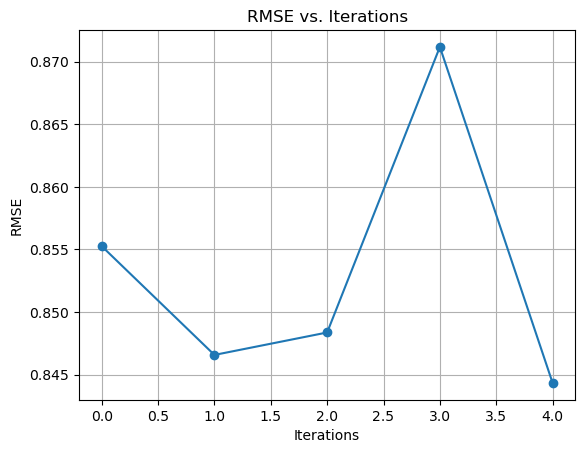

In [53]:
# Plot
plt.plot(iterations, rmse_vals, marker='o', linestyle='-')
plt.xlabel('Iterations')
plt.ylabel('RMSE')
plt.title('RMSE vs. Iterations')
plt.grid(True)
plt.show()

In [58]:
avg_rmse = np.mean(rmse_vals)
avg_rmse

0.8531445057806735